# 3. Preparación de los datos

## 3.1 Cambios de formato

#### Conversión de columnas numéricas

Las columnas identificadas como numéricas en el diccionario `meta` se convierten explícitamente a tipo `float`. Los valores que no puedan convertirse (por ejemplo, textos o símbolos) se transforman en `NaN` para su posterior tratamiento.

In [31]:
columnas_numericas = [col for col, (tipo, _) in meta.items() if tipo == 'Numérico' and col in df.columns]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

display(HTML("<div style='text-align: center; font-family: Roboto, sans-serif;'>Conversión de columnas numéricas completada.</div>"))

#### Estandarización de variables booleanas

Las variables booleanas se estandarizan a valores numéricos `1` (verdadero) y `0` (falso). Los valores no reconocidos se convierten a `NaN`.

In [32]:
import numpy as np

bool_cols = [col for col, (tipo, _) in meta.items() if tipo == 'Booleano' and col in df.columns]

def estandarizar_booleano(valor):
    if pd.isna(valor):
        return valor
    valor = str(valor).strip().lower()
    if valor in ['1', 'true', 'positivo', 'ingresado', 'si', 'sí']:
        return 1
    if valor in ['0', 'false', 'negativo', 'no', 'ambulatorio']:
        return 0
    return np.nan

for col in bool_cols:
    df[col] = df[col].apply(estandarizar_booleano)

display(HTML("<div style='text-align: center; font-family: Roboto, sans-serif;'>Estandarización de booleanos completada (0/1).</div>"))

## 3.2 Limpieza de datos

Una vez unificados los formatos, aplicamos las acciones correctivas documentadas en *2.2 Establecimiento de volumen de la información* , respetando el orden lógico que evita la propagación de errores.

### 1. Simplificamos formatos compuestos

Descomponemos valores como *150/97* en `presion_sistolica = 150` y `presion_diastolica = 97` respectivamente.

In [33]:
presion_original = pd.read_csv('dataset_salud_nayarit.csv', encoding='utf-8-sig', usecols=['presion_sistolica'])

split_df = presion_original['presion_sistolica'].astype(str).str.split('/', n=1, expand=True)
split_df.columns = ['sistolica_temp', 'diastolic_temp']

df['presion_sistolica'] = pd.to_numeric(split_df['sistolica_temp'], errors='coerce')
df['diastolic_temp'] = pd.to_numeric(split_df['diastolic_temp'], errors='coerce')
df['presion_diastolica'] = df['presion_diastolica'].fillna(df['diastolic_temp'])
df = df.drop(columns=['diastolic_temp'])

### 2. Eliminamos registros duplicados

Eliminamos los 10 registros idénticos detectados, ya que representan consultas ingresadas más de una vez por error de captura.

In [34]:
df = df.drop_duplicates()
display(HTML(f"<div style='text-align: center;'>Registros después de eliminar duplicados: {len(df)}</div>"))

### 3. Homologamos unidades de medida

Los valores de `talla_cm` inferiores a 3.0 fueron capturados en metros en lugar de centímetros. Los multiplicamos por 100 para homogeneizar la unidad.

In [35]:
metros = (df['talla_cm'] < 3.0) & (df['talla_cm'].notna())
df.loc[metros, 'talla_cm'] = df.loc[metros, 'talla_cm'] * 100
display(HTML(f"<div style='text-align: center;'>Registros con talla corregida de metros a centímetros: {metros.sum()}</div>"))

### 4. Estandarizamos variables categóricas

A continuación se realiza la estandarización para `municipio`, `género`, `escolaridad`

In [36]:
df['municipio'] = df['municipio'].astype(str).str.strip()

genero_map = {
    'F': 'F', 'f': 'F', 'Femenino': 'F', 'femenino': 'F', 'FEMENINO': 'F', 'Mujer': 'F',
    'M': 'M', 'm': 'M', 'Masculino': 'M', 'masculino': 'M', 'MASCULINO': 'M', 'Hombre': 'M', 'H': 'M', 'Fem': 'F'
}
df['genero'] = df['genero'].map(genero_map)

bad_edu = ['--', 'ND', '?', 'SIN DATO', 'Sin dato', '999']
df['escolaridad'] = df['escolaridad'].apply(lambda x: np.nan if str(x).strip() in bad_edu else x)

display(HTML("<div style='text-align: center; font-family: Roboto, sans-serif;'>Estandarización de variables categóricas problemáticas completada.</div>"))

### 5. Convertimos valores fuera de dominio

Los valores numéricos que están fuera de rangos fisiológicos plausibles se transforman en `NaN` para posterior imputación. Ajustamos la edad al rango 0‑120 años, la glucosa entre 20‑1000 mg/dL, el colesterol entre 50‑500 mg/dL (y el código especial 999), los triglicéridos entre 20‑2000 mg/dL, y la talla entre 25‑272 cm.

In [37]:
import numpy as np


df.loc[(df['edad'] < 0) | (df['edad'] > 120), 'edad'] = np.nan

df.loc[(df['glucosa_mg_dl'] < 20) | (df['glucosa_mg_dl'] > 1000), 'glucosa_mg_dl'] = np.nan

df.loc[(df['colesterol_mg_dl'] < 50) | (df['colesterol_mg_dl'] > 500) | (df['colesterol_mg_dl'] == 999), 'colesterol_mg_dl'] = np.nan

df.loc[(df['trigliceridos_mg_dl'] < 20) | (df['trigliceridos_mg_dl'] > 2000), 'trigliceridos_mg_dl'] = np.nan

df.loc[(df['talla_cm'] < 25) | (df['talla_cm'] > 272), 'talla_cm'] = np.nan
display(HTML("<div style='text-align: center;'>Valores fuera de dominio convertidos a NaN.</div>"))

### 6. Imputamos valores nulos numéricos

Para preservar la mayor cantidad de registros, rellenamos los vacíos numéricos con la mediana de cada columna. La mediana es robusta frente a valores extremos y mantiene la tendencia central.

In [38]:
import warnings
warnings.filterwarnings('ignore')

for col in df.select_dtypes(include=[np.number]).columns:
    if col != 'hospitalizacion':
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
display(HTML("<div style='text-align: center;'>Nulos numéricos imputados con la mediana.</div>"))

### 7. Imputamos nulos categóricos

Las columnas de tipo objeto (categóricas) se rellenan con la categoría más frecuente (moda) para no perder información y evitar sesgos.

In [39]:
import warnings
warnings.filterwarnings('ignore')

for col in df.select_dtypes(include=['object']).columns:
    moda = df[col].mode()
    if not moda.empty:
        df[col].fillna(moda[0], inplace=True)
    else:
        df[col].fillna('Desconocido', inplace=True)
display(HTML("<div style='text-align: center;'>Nulos categóricos imputados con la moda.</div>"))

### 8. Recalculamos el IMC

El IMC es un campo calculado. Una vez imputados peso y talla, recalculamos el IMC para los registros donde aún fuera nulo, garantizando coherencia.

In [40]:
mask_imc_nulo = df['imc'].isna()
df.loc[mask_imc_nulo, 'imc'] = df.loc[mask_imc_nulo, 'peso_kg'] / (df.loc[mask_imc_nulo, 'talla_cm'] / 100) ** 2
display(HTML(f"<div style='text-align: center;'>IMC recalculado.</div>"))

### 9. Verificamos los resultados

Mostramos un resumen final de los datos limpios para confirmar que no persistan valores nulos.

In [41]:
display(HTML(f"<div style='text-align: center;'>Registros finales después de limpieza: {len(df)}</div>"))
display(HTML(f"<div style='text-align: center;'>Columnas: {df.shape[1]}</div>"))
total_nulos = df.isnull().sum().sum()
display(HTML(f"<div style='text-align: center;'>Nulos restantes en total: {total_nulos}</div>"))

## 3.3 Generación de variables adicionales

Con los datos ya limpios y tipificados, enriqueceremos el conjunto de características mediante **clustering no supervisado**. Aplicamos **K‑Means** sobre las variables numéricas (edad, peso, presión, glucosa, etc.) después de normalizarlas con `StandardScaler`. El número óptimo de clústeres se determinó previamente mediante el método del codo (k=3). Las etiquetas de clúster se concatenan al DataFrame original. De esta forma, el modelo de clasificación podrá capturar perfiles de pacientes que no son evidentes mediante las variables individuales, mejorando potencialmente el poder predictivo.

### Paso 1: Seleccionamos variables clusterizables

Definimos la lista de columnas numéricas que se utilizarán para agrupar a los pacientes.

In [42]:
numeric_cols_to_cluster = ['edad', 'peso_kg', 'talla_cm', 'imc', 
                           'presion_sistolica', 'presion_diastolica', 
                           'glucosa_mg_dl', 'colesterol_mg_dl', 
                           'trigliceridos_mg_dl', 'hemoglobina_g_dl', 
                           'num_medicamentos_actuales', 'num_consultas_ano_prev']

### Paso 2: Normalizamos los datos

Para que todas las variables contribuyan por igual al cálculo de distancias en K‑Means, aplicamos una normalización con `StandardScaler`.

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(df[numeric_cols_to_cluster])

### Paso 3: Aplicamos K‑Means

Usamos el algoritmo K‑Means con 3 clústeres.

In [44]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_numeric_scaled)

### Paso 4: Visualizamos clústeres con Bokeh

Para comprender la estructura de los clústeres, primero reducimos la dimensionalidad con PCA, analizamos la contribución de cada variable y finalmente proyectamos los pacientes en un gráfico interactivo.

#### Reducimos dimensionalidad

Aplicamos PCA a los datos normalizados para proyectar los pacientes en dos dimensiones principales.

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric_scaled)

display(HTML(f"<div style='text-align: center; font-family: Roboto, sans-serif;'>Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.4f}, PC2: {pca.explained_variance_ratio_[1]:.4f}</div>"))

#### Visualizamos loadings y una tabla de contribuciones

Los loadings indican cuánto contribuye cada variable original a los componentes. A continuación se muestra una tabla con los coeficientes y un gráfico de barras para PC1 y PC2.

In [46]:
import pandas as pd
from IPython.display import display, HTML

loadings = pca.components_.T
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=numeric_cols_to_cluster)

styled_df = loadings_df.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px')]},
    {'selector': 'td', 'props': [('padding', '6px')]}
]).set_properties(**{'text-align': 'center'})

display(HTML("<div style='text-align: center; font-family: Roboto, sans-serif;'>Contribución de cada variable a los componentes principales:</div>"))
display(HTML(f'<div style="display: flex; justify-content: center;">{styled_df.to_html()}</div>'))

,PC1,PC2
edad,0.554617,-0.209205
peso_kg,0.058674,0.294617
talla_cm,-0.070758,-0.404538
imc,0.148459,0.545829
presion_sistolica,0.534326,-0.047043
presion_diastolica,0.452325,0.014360
glucosa_mg_dl,0.125967,0.525570
colesterol_mg_dl,0.015887,0.012181
trigliceridos_mg_dl,0.033505,0.067839
hemoglobina_g_dl,-0.020064,-0.160055


##### Dichas contribuciones pueden ser mejor observadas a continuación


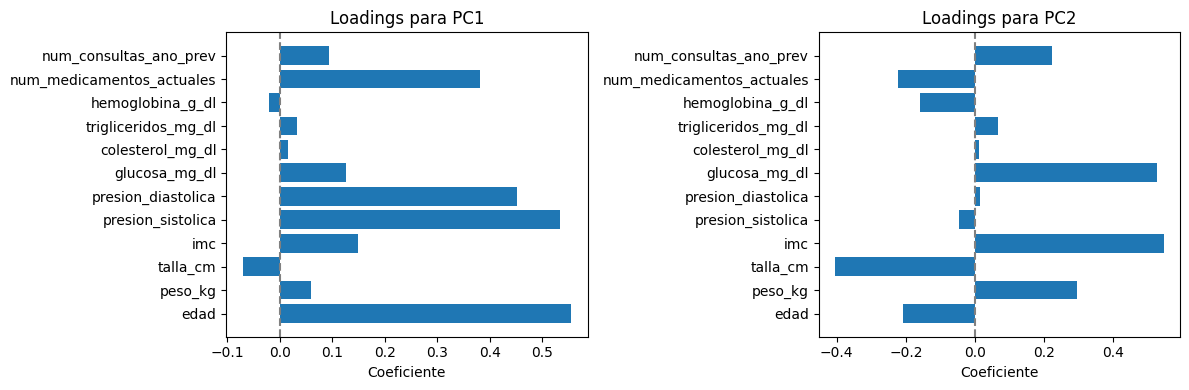

In [47]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.barh(numeric_cols_to_cluster, loadings_df.iloc[:, i])
    ax.set_title(f'Loadings para PC{i+1}')
    ax.set_xlabel('Coeficiente')
    ax.axvline(0, color='gray', linestyle='--')
plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')
plt.close()

display(HTML(f'''
<div style="display: flex; justify-content: center;">
    <img src="data:image/png;base64,{img_base64}"
         style="max-width: 50vw !important; height: auto !important;
                border-radius: 0 !important; box-shadow: none !important;">
</div>
'''))

##### A través de estos datos, podemos observar la siguiente agrupación de variables por medio de su contribución en los componentes

In [81]:
import pandas as pd
from IPython.display import display, HTML

loadings = pca.components_.T
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=numeric_cols_to_cluster)

max_component = loadings_df.idxmax(axis=1)
pc1_vars = max_component[max_component == 'PC1'].index.tolist()
pc2_vars = max_component[max_component == 'PC2'].index.tolist()

pc1_table = pd.DataFrame({'Variable': pc1_vars, 'Contribución en PC1': loadings_df.loc[pc1_vars, 'PC1'].values})
pc2_table = pd.DataFrame({'Variable': pc2_vars, 'Contribución en PC2': loadings_df.loc[pc2_vars, 'PC2'].values})

def style_table(df):
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px')]}
    ]).set_properties(**{'text-align': 'center'}).hide(axis='index')

display(HTML("<div style='text-align: center; font-family: Roboto, sans-serif; margin-bottom: 10px;'>Variables asignadas a PC1 (mayor contribución absoluta):</div>"))
display(HTML(f'<div style="display: flex; justify-content: center;">{style_table(pc1_table).to_html()}</div>'))

display(HTML("<div style='text-align: center; font-family: Roboto, sans-serif; margin: 20px 0 10px 0;'>Variables asignadas a PC2 (mayor contribución absoluta):</div>"))
display(HTML(f'<div style="display: flex; justify-content: center;">{style_table(pc2_table).to_html()}</div>'))

Variable,Contribución en PC1
edad,0.554617
talla_cm,-0.070758
presion_sistolica,0.534326
presion_diastolica,0.452325
colesterol_mg_dl,0.015887
hemoglobina_g_dl,-0.020064
num_medicamentos_actuales,0.381248


Variable,Contribución en PC2
peso_kg,0.294617
imc,0.545829
glucosa_mg_dl,0.525570
trigliceridos_mg_dl,0.067839
num_consultas_ano_prev,0.221736


##### Por lo que podemos concluir la propiedad del dataset que representa cada componente

A través de los datos observados, entendemos que el primer componente representa el **envejecimiento y la carga cardiovascular** , mientras que el segundo componente representa el **estado metabólico y nutricional** del paciente.

#### Hacemos un gráfico interactivo de los clústeres con Bokeh

Proyectamos los pacientes en el plano PCA y coloreamos cada punto según la etiqueta de clúster obtenida con K‑Means. El gráfico permite explorar la separación de los grupos.


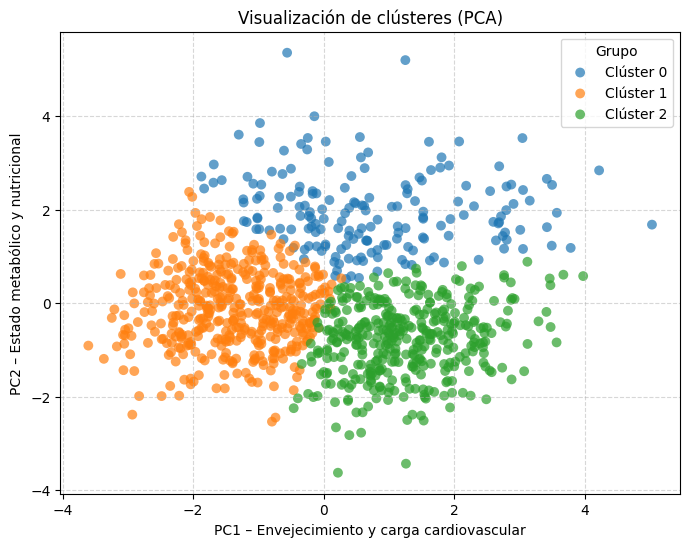

In [49]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
cluster_colors = [colores[c] for c in clusters]

fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id in set(clusters):
    mask = clusters == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colores[cluster_id], label=f'Clúster {cluster_id}',
               s=50, alpha=0.7, edgecolors='none')

ax.set_title("Visualización de clústeres (PCA)")
ax.set_xlabel("PC1 – Envejecimiento y carga cardiovascular")
ax.set_ylabel("PC2 – Estado metabólico y nutricional")
ax.legend(title="Grupo")
ax.grid(True, linestyle='--', alpha=0.5)

buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')
plt.close()

display(HTML(f'''
<div style="display: flex; justify-content: center;">
    <img src="data:image/png;base64,{img_base64}"
         style="max-width: 100%; height: auto; border-radius: 0; box-shadow: none;">
</div>
'''))

##### A partir de dicho gráfico, rescatamos las siguientes conclusiones

Los tres grupos reflejan perfiles clínicos distintos: el grupo de **bajo PC1 y bajo PC2** corresponde a pacientes jóvenes y metabólicamente sanos. El grupo de **alto PC1 y bajo PC2** son pacientes con envejecimiento y carga cardiovascular elevada (hipertensión, polifarmacia) pero sin alteraciones metabólicas importantes. El grupo de **PC1 medio y PC2 alto** representa a pacientes con predominio de problemas metabólicos (obesidad, diabetes, dislipidemia) y un riesgo cardiovascular intermedio.

##### A continuación, generamos una gráfica para analizar la tasa de hospitalización por clúster


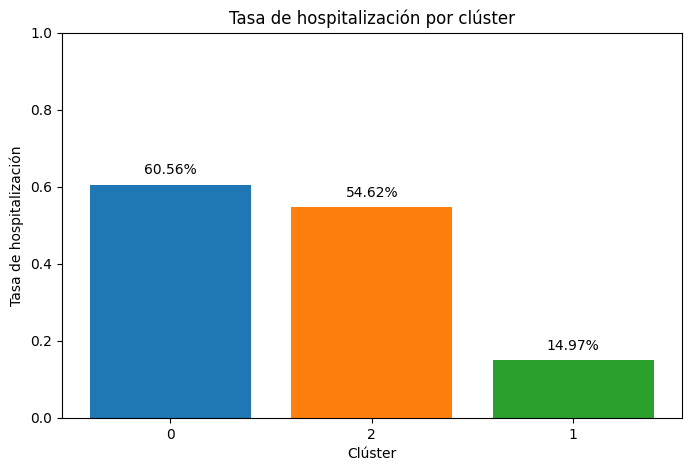

In [50]:
df_cluster = df.copy()
df_cluster['cluster'] = clusters
hospitalization_rate = df_cluster.groupby('cluster')['hospitalizacion'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(hospitalization_rate.index.astype(str), hospitalization_rate.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_xlabel('Clúster')
ax.set_ylabel('Tasa de hospitalización')
ax.set_title('Tasa de hospitalización por clúster')
ax.set_ylim(0, 1)

for bar, rate in zip(bars, hospitalization_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{rate:.2%}', ha='center', va='bottom')

buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')
plt.close()

display(HTML(f'''
<div style="display: flex; justify-content: center;">
    <img src="data:image/png;base64,{img_base64}"
         style="max-width: 100% !important; height: auto !important;
                border-radius: 0 !important; box-shadow: none !important;">
</div>
'''))

Con esta representación podemos observar que el clúster de mayor riesgo es el #0, y el de mayor riesgo es el #1

### Paso 5: Renombramos las variables de clúster

Con base en la tasa de hospitalización observada en cada clúster, renombramos las etiquetas numéricas (0, 2, 1) como **RiesgoAlto** , **RiesgoMedio** y **RiesgoBajo** respectivamente. De esta forma, la variable de clúster se convierte en una característica ordinal que refleja directamente el nivel de riesgo de hospitalización, lo que facilita su interpretación en el modelo predictivo.

In [51]:
cluster_risk = pd.Series(clusters).map({0: 'RiesgoAlto', 2: 'RiesgoMedio', 1: 'RiesgoBajo'})
df['cluster_risk'] = cluster_risk

### Paso 6: Concatenamos las nuevas variables

Reajustamos los índices para evitar desalineaciones y añadimos las columnas dummy al conjunto de datos.

In [52]:
df = df.reset_index(drop=True)
df['cluster_risk'] = cluster_risk

### Paso 7: Verificamos el resultado

Mostramos la nueva dimensión del DataFrame y el nombre de las columnas generadas.

In [53]:
display(HTML(f"<div style='text-align: center; font-family: Roboto, sans-serif;'>Dimensiones después de añadir variable de riesgo: {df.shape}</div>"))
display(HTML(f"<div style='text-align: center; font-family: Roboto, sans-serif;'>Nueva columna generada: cluster_risk</div>"))

In [54]:
df["cluster_risk"].unique()

array(['RiesgoBajo', 'RiesgoMedio', 'RiesgoAlto'], dtype=object)

## 3.4 Selección de características

### 1. Descartamos columnas

Removemos la columna `id_paciente` ya que no son estará disponible en la vida real, por lo que representan una fuga de datos (*Data Leakage*) del dataset.

In [55]:
df = df.drop(columns=['id_paciente'])

### 2. Aplicamos sobremuestreo (*oversampling*)

#### ¿Qué es el sobremuestreo y por qué es necesario?

Las tareas de clasificación con datasets desbalanceados, donde una clase (en este caso, los pacientes **hospitalizados**) está significativamente subrepresentada, suponen un desafío persistente en el aprendizaje automático. Esta disparidad puede sesgar el modelo hacia la clase mayoritaria, perjudicando la detección de la clase minoritaria. Para abordar esto, se emplean técnicas de remuestreo, siendo el [sobremuestreo](https://www.ibm.com/mx-es/think/topics/upsampling#:~:text=El%20sobremuestreo%2C%20tambi%C3%A9n,el%20mismo%20tama%C3%B1o.) una estrategia fundamental.

![](media/oversampling.png)

#### A continuación aplicamos dicha técnica

In [56]:
temp = df.copy()
class_0 = temp[temp['hospitalizacion'] == 0]
class_1 = temp[temp['hospitalizacion'] == 1]

if len(class_0) > len(class_1):
    class_1_over = class_1.sample(len(class_0), replace=True, random_state=42)
    df_balanced = pd.concat([class_0, class_1_over], axis=0)
else:
    class_0_over = class_0.sample(len(class_1), replace=True, random_state=42)
    df_balanced = pd.concat([class_1, class_0_over], axis=0)

X_bal = df_balanced.drop('hospitalizacion', axis=1)
y_bal = df_balanced['hospitalizacion']

### 3. Discretizamos variables

Convertimos las variables numéricas en indicadores binarios mediante *one-hot encoding*.

In [57]:
df_encoded = pd.get_dummies(df_balanced, drop_first=False)
X = df_encoded.drop('hospitalizacion', axis=1)
y = df_encoded['hospitalizacion']

### 4. Seleccionamos características

Para esta selección de características, hemos utilizado la librería `featureranker`. Se trata de una herramienta ligera de Python que combina un conjunto de cinco métodos de ranking para determinar la importancia de las características, tanto para tareas de clasificación como de regresión. A continuación, explicamos más a detalle cada dato técnico de la herramienta:

#### ¿Qué es featureranker?

`featureranker` es un paquete de Python que orquesta un ensamble de métodos de ranking de características, utilizando un esquema de votación ponderada para consolidar los resultados. La librería fue desarrollada por **Logan Hallee** , [científico computacional y candidato a doctorado en Bioinformática en la Universidad de Delaware](https://github.com/lhallee#:~:text=scientist%20working%20on,transformer%20neural%20networks.), quien también es fundador de la organización de investigación [Synthyra](https://synthyra.com/). El proyecto está disponible en [su repositorio oficial en GitHub](https://github.com/lhallee/featureranker).

![](media/Logan-Hallee-Footer.jpg)

La librería ha sido citada y utilizada en trabajos académicos y aplicaciones de ciencia de datos, como se menciona a continuación:

##### [Machine learning classifiers predict key genomic and evolutionary traits across the kingdoms of life](https://github.com/lhallee/featureranker#:~:text=Featured%20in%3A-,Machine%20learning%20classifiers%20predict%20key%20genomic%20and%20evolutionary%20traits%20across%20the%20kingdoms%20of%20life,-.Nature%20Scientific%20Reports)

Publicado en *Scientific Reports* (Nature, 2023), este trabajo demuestra cómo el sesgo de uso de [codones de un organismo](https://www.cancer.gov/espanol/publicaciones/diccionarios/diccionario-genetica/def/codon#:~:text=una%20secuencia%20de%203%20nucle%C3%B3tidos%20consecutivos%20que%20codifica%20un%20amino%C3%A1cido%20espec%C3%ADfico) puede servir como predictor de rasgos evolutivos y genómicos. Entrenando modelos de aprendizaje automático con patrones de casi 13,000 organismos, los autores lograron predecir con precisión la identidad taxonómica y el origen de orgánulos de muestras de nucleótidos. El estudio validó la efectividad del [ensamble de selección de características utilizado por `featureranker`](https://www.nature.com/articles/s41598-023-28965-7#:~:text=We%20extend%20our%20analysis%20to%20identify%20the%20most%20influential%20codons%20for%20phylogenetic%20prediction%20with%20a%20custom%20feature%20ranking%20ensemble.) para identificar los codones más influyentes en la predicción filogenética.

![](media/Machine-learning-classifiers-predict-key-genomic-and-evolutionary-traits-across-the-kingdoms-of-life.webp)

##### [cdsBERT - Extending Protein Language Models with Codon Awareness](https://github.com/lhallee/featureranker)

Publicado en *bioRxiv* (2023), este trabajo extiende los modelos de lenguaje de proteínas tradicionales al incorporar el nivel de codones. La metodología, denominada cdsBERT (*coding sequence BERT*), tokeniza las secuencias a nivel de codón en lugar de aminoácidos, lo que mejora la predicción de la expresión génica, la estabilidad del ARN y la localización subcelular. Al emplear la librería `featureranker`, los autores identificaron los codones con mayor poder predictivo para la expresión de proteínas, validando así el enfoque de ensamble de selección de características utilizado en nuestro análisis.

![](media/cdsBERT-Extending-Protein-Language-Models-with-Codon-Awareness.jpg)

#### Estado de mantenimiento de la librería

`featureranker` se encuentra en desarrollo activo y cuenta con soporte para múltiples métodos de ranking. El [último release en su repositorio oficial fue realizado el 4 de abril de 2026](https://github.com/lhallee/featureranker/releases/tag/2.0.0#:~:text=lhallee-,released%20this%20Apr%203,-2.0.0) (para la v2.0.0), lo que indica que la librería se mantiene actualizada por su creador.

#### Reseñas de la comunidad

La comunidad ha recibido positivamente esta herramienta, valorando su simplicidad y la efectividad del enfoque de ensamble. El repositorio oficial en GitHub cuenta actualmente con [7 estrellas](https://github.com/lhallee/featureranker/stargazers), lo que refleja el interés y la aceptación de los desarrolladores.

![](media/Stargazers.jpg)

#### Algoritmos de selección de características

`featureranker` integra cinco métodos fundamentales para calcular la relevancia de las características. A continuación, se describen brevemente los algoritmos utilizados por esta librería.

##### Algoritmo 1: Random Forest (RF)

Este método entrena un modelo de Random Forest (con ajuste de hiperparámetros) y utiliza la importancia de las características calculada a partir del modelo para generar un ranking. Es robusto frente a sobreajuste y no linealidades.

![](media/Random-Forest.gif)

##### Algoritmo 2: XGBoost (XG)

Similar al Random Forest, este método entrena un modelo XGBoost optimizado y utiliza las importancias derivadas del modelo para clasificar las características. XGBoost es conocido por su eficiencia y capacidad para manejar datos con relaciones complejas.

![](media/XGBoost.gif)

##### Algoritmo 3: Información Mutua (MI)

Este método estadístico mide la dependencia mutua entre cada característica y la variable objetivo, capturando tanto relaciones lineales como no lineales.

![](media/MI.gif)

##### Algoritmo 4: ANOVA F-test (F-Test)

Calcula el estadístico F de ANOVA para evaluar la relación lineal entre cada característica y la variable dependiente. Es un método clásico y computacionalmente eficiente.

![](media/ANOVAFTest.jpg)

##### Algoritmo 5: Regularización L1

Emplea un análisis de la ruta de regularización L1. Este método es efectivo para la selección de características, ya que tiende a llevar los coeficientes de las características irrelevantes a cero.

![](media/Regularization.gif)

#### Aplicamos la selección de características con `featureranker`

Una vez balanceadas las clases, ejecutamos `featureranker` sobre el conjunto sobremuestreado. La función `feature_ranking()` aplica los cinco métodos descritos (Random Forest, XGBoost, Información Mutua, F‑test y L1) y devuelve una lista de rankings. Posteriormente, la función `voting()` agrega estos rankings mediante el método de *reciprocal rank* para obtener una puntuación consolidada por característica. Seleccionamos las 10 mejores características para el modelado final y salvamos los resultados.

In [58]:
import hashlib
import pickle
from featureranker import feature_ranking, voting

def feature_cache_key(X):
    cols = sorted(X.columns)
    key_str = ",".join(cols)
    return hashlib.md5(key_str.encode()).hexdigest()

cache_file = "feature_cache.pkl"
try:
    with open(cache_file, "rb") as f:
        cache = pickle.load(f)
except (FileNotFoundError, EOFError):
    cache = {}

cluster_cols = [col for col in X.columns if col.startswith('cluster_risk_')]
X_no_risk = X.drop(columns=cluster_cols)
key = feature_cache_key(X_no_risk)

if key in cache:
    aggregated = cache[key]["aggregated"]
    selected_features = cache[key]["selected_features"]
    rankings = cache[key]["rankings"]
else:
    rankings = feature_ranking(X_no_risk, y, task='classification', n_jobs=-1)
    aggregated = voting(rankings, method='reciprocal_rank')
    top_k = 10
    selected_features = aggregated.head(top_k)['Feature'].tolist()
    cache[key] = {
        "aggregated": aggregated,
        "selected_features": selected_features,
        "rankings": rankings,
    }
    with open(cache_file, "wb") as f:
        pickle.dump(cache, f)

top_k = 10
selected_features = aggregated.head(top_k)['Feature'].tolist()

### 5. Visualizamos los rankings

#### Observamos una representación tabular de los rankings

La siguiente tabla muestra las 10 características con mayor puntuación agregada (Score), ordenadas de mayor a menor. El Score es el resultado de la votación por rango recíproco normalizada, donde valores más altos indican mayor relevancia para predecir la hospitalización.

In [82]:
top_features_df = aggregated.head(top_k)[['Feature', aggregated.columns[1]]].copy()
top_features_df.columns = ['Característica', 'Score']
top_features_df.index = range(1, len(top_features_df) + 1)

styled_table = top_features_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal',
    'word-wrap': 'break-word',
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('white-space', 'normal'), ('text-align', 'left')]},
    {'selector': 'td', 'props': [('padding', '6px')]},
    {'selector': 'table', 'props': [('width', 'auto'), ('margin-left', 'auto'), ('margin-right', 'auto'), ('border-collapse', 'collapse')]}
])

display(HTML(f'<div style="display: flex; justify-content: center; width: 100%;">{styled_table.to_html()}</div>'))

,Característica,Score
1,edad,3.750000
2,presion_sistolica,1.757576
3,hipertension_previa,1.668050
4,diabetes_previa,1.195826
5,ocupacion_Profesionista,1.060970
6,peso_kg,0.839796
7,presion_diastolica,0.721429
8,num_medicamentos_actuales,0.656153
9,imc,0.648538
10,talla_cm,0.471001


#### Observamos una representación gráfica de los rankings

A continuación se muestra un gráfico de barras horizontales que facilita la comparación visual de la importancia relativa de cada característica seleccionada.


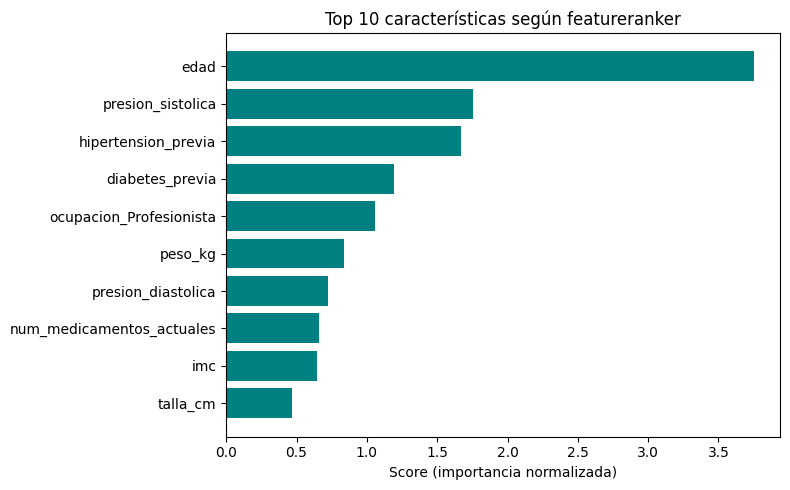

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import base64
import io

features = top_features_df['Característica'].values[::-1]
scores = top_features_df['Score'].values[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features, scores, color='teal')
ax.set_xlabel('Score (importancia normalizada)')
ax.set_title('Top 10 características según featureranker')
plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64_franking = base64.b64encode(buf.read()).decode('utf-8')
plt.close()

display(HTML(f'''
<div style="display: flex; justify-content: center;">
    <img src="data:image/png;base64,{img_base64_franking}"
         style="max-width: 100% !important; height: auto !important;
                border-radius: 0 !important; box-shadow: none !important;">
</div>
'''))

#### A partir de las previas observaciones, concluimos lo siguiente

El ranking destaca que la **edad** es, con mucha diferencia, la característica más predictiva, seguida de **diabetes_previa** y la variable **presion_sistolica** (generada por K‑Means). Esto sugiere que la edad y los indicadores químicos tienen mucha influencia sobre la variable objetivo.

### 6. Aislamos las características seleccionadas.

In [61]:
df_over = df_encoded[selected_features + ['hospitalizacion']]
display(HTML(f"<div style='text-align: center; font-family: Roboto, sans-serif;'>Dimensiones del conjunto balanceado con características seleccionadas: {df_over.shape}</div>"))